# Vicarious gain QC

Inspect spectral `vcal_gain` NetCDFs from `compute_vcal_gain.jl`:

$$g(\lambda) = 1 + \mathrm{residual}(\lambda) / R_\mathrm{toa}(\lambda)$$

Pixels with missing L2 AOP `nflh` are NaN in `vcal_gain`. This notebook plots the spatial mean spectrum and means binned by `nflh` / `chlor_a`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

%matplotlib inline

In [2]:
# One granule produced by: julia --project=. vcal_gain/compute_vcal_gain.jl vcal_gain/vcal_gain.toml
granule_id = "20250125T094057"
root_dir = Path("/home/zhe2/data/PACE/new_svd_retrieval_output/vcal_gain")
nc_path = root_dir / f"vcal_gain_interim_{granule_id}_svd_retrieval.nc"

ds = xr.open_dataset(nc_path)
wavelength = ds["wavelength"]          # (wavelength,)
vcal_gain = ds["vcal_gain"]            # (wavelength, scans, pixels)
nflh = ds["nflh"]                      # (scans, pixels)
chlor_a = ds["chlor_a"]                # (scans, pixels)

print(nc_path.name)
print(f"shape vcal_gain={tuple(vcal_gain.shape)}  valid nflh={int(ds.attrs.get('n_pixels_valid_nflh', -1))}")
ds

vcal_gain_interim_20250125T094057_svd_retrieval.nc
shape vcal_gain=(83, 1709, 1272)  valid nflh=38238


<xarray.Dataset> Size: 774MB
Dimensions:             (wavelength: 83, scans: 1709, pixels: 1272)
Coordinates:
  * wavelength          (wavelength) float64 664B 641.0 642.2 ... 754.3 755.5
Dimensions without coordinates: scans, pixels
Data variables:
    latitude            (scans, pixels) float32 9MB ...
    longitude           (scans, pixels) float32 9MB ...
    vcal_gain           (wavelength, scans, pixels) float32 722MB ...
    nflh                (scans, pixels) float32 9MB ...
    chlor_a             (scans, pixels) float32 9MB ...
    sif_radiance_678nm  (scans, pixels) float32 9MB ...
    converged           (scans, pixels) float32 9MB ...
Attributes: (12/13)
    title:                          PACE vicarious gain (spectral)
    granule_id:                     20250125T094057
    gain_formula:                   vcal_gain = 1 + residual/Rtoa
    residual_source:                svd_fm_xhat_minus_l1b_rtoa
    retrieval_file:                 /home/zhe2/data/PACE/new_svd_retrieval_ou...
    l2aop_file:                     /kiwi-data/Data/satellite/PACE_OCI/L2_AOP...
    ...                             ...
    l1b_file:                       /kiwi-data/Data/satellite/PACE_OCI/L1B_V3...
    svd_config:                     /home/zhe2/FraLab/PACE_redSIF_PACE/svd_co...
    svd_solar_eff_convention:       also_in_solar_eff (double-π era; med|ŷ/y-...
    n_pixels_valid_nflh:            38238
    n_pixels_skipped_missing_nflh:  2135610
    history:                        Created 2026-09-22T17:21:25

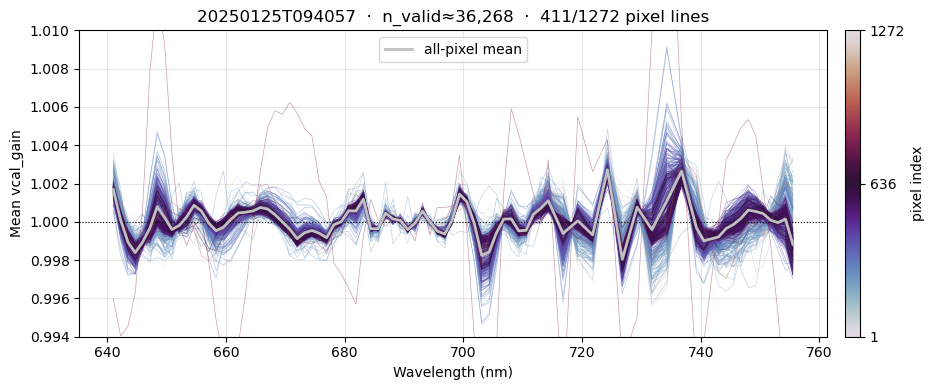

In [18]:
# Per-pixel mean (over scans) + full spatial mean; color = pixel index (1–1272)
mean_gain_per_pixel = vcal_gain.mean(dim="scans", skipna=True)  # (wavelength, pixels)
mean_gain = vcal_gain.mean(dim=("scans", "pixels"), skipna=True)
n_valid = int(np.isfinite(vcal_gain.isel(wavelength=0).values).sum())

g = np.asarray(mean_gain_per_pixel.values)  # (λ, pixels)
n_pix = g.shape[1]
cmin, cmax = 1, 1272  # pixel index (1-based)
pix_ok = np.flatnonzero(np.isfinite(g).any(axis=0))
# Cap for readability if many pixels have data
max_lines = 400
if pix_ok.size > max_lines:
    pix_ok = pix_ok[:: max(1, pix_ok.size // max_lines)]

fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.cm.twilight  # cyclic
norm = plt.Normalize(vmin=cmin, vmax=cmax)
for j in pix_ok:
    pix_idx = j + 1  # 1-based
    ax.plot(wavelength, g[:, j], color=cmap(norm(pix_idx)), lw=0.5, alpha=0.45)
ax.plot(wavelength, mean_gain, color="silver", lw=2.0, label="all-pixel mean", zorder=5)
ax.axhline(1.0, color="k", ls=":", lw=0.8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("pixel index")
cbar.set_ticks([cmin, (cmin + cmax) // 2, cmax])

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean vcal_gain")
ax.set_ylim(0.994, 1.01)
ax.set_title(f"{granule_id}  ·  n_valid≈{n_valid:,}  ·  {pix_ok.size}/{n_pix} pixel lines")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


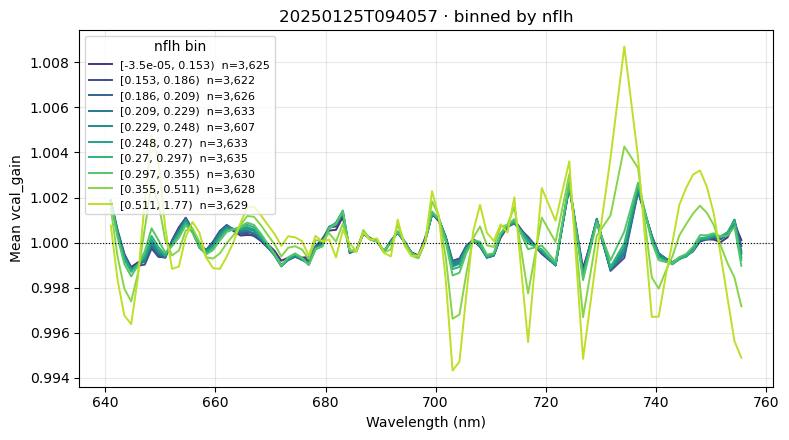

In [23]:
# Bin pixels by nflh (quantile edges) and plot mean vcal_gain(λ) per bin
nflh_vals = nflh.values.ravel()
gain_2d = vcal_gain.values.reshape(vcal_gain.sizes["wavelength"], -1)  # (λ, N)

valid = np.isfinite(nflh_vals) & np.isfinite(gain_2d).any(axis=0)
nflh_v = nflh_vals[valid]
gain_v = gain_2d[:, valid]

n_bins = 10
edges = np.unique(np.nanquantile(nflh_v, np.linspace(0, 1, n_bins + 1)))
if len(edges) < 3:
    edges = np.linspace(np.nanmin(nflh_v), np.nanmax(nflh_v), n_bins + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(edges) - 1))
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    if i < len(edges) - 2:
        m = (nflh_v >= lo) & (nflh_v < hi)
    else:
        m = (nflh_v >= lo) & (nflh_v <= hi)
    if m.sum() == 0:
        continue
    mean_b = np.nanmean(gain_v[:, m], axis=1)
    ax.plot(
        wavelength,
        mean_b,
        color=cmap[i],
        lw=1.4,
        label=f"[{lo:.3g}, {hi:.3g})  n={m.sum():,}",
    )

ax.axhline(1.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean vcal_gain")
ax.set_title(f"{granule_id} · binned by nflh")
ax.legend(title="nflh bin", fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


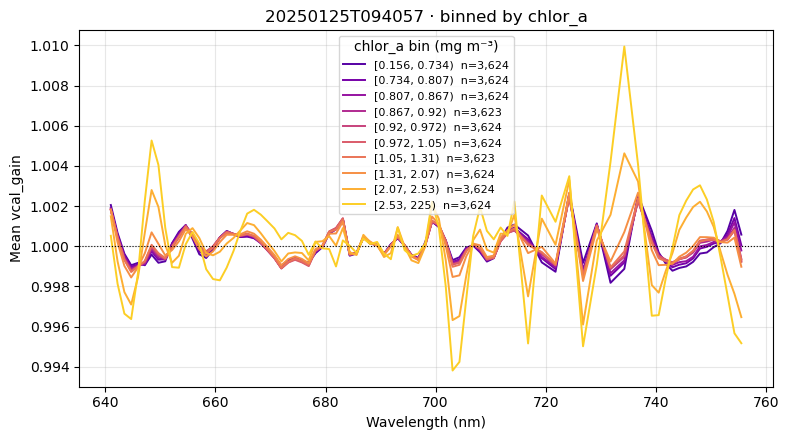

In [24]:
# Bin pixels by chlor_a (quantile / log edges) and plot mean vcal_gain(λ) per bin
chl_vals = chlor_a.values.ravel()
gain_2d = vcal_gain.values.reshape(vcal_gain.sizes["wavelength"], -1)  # (λ, N)

valid_c = (
    np.isfinite(chl_vals)
    & (chl_vals > 0)
    & np.isfinite(gain_2d).any(axis=0)
)
chl_v = chl_vals[valid_c]
gain_c = gain_2d[:, valid_c]

n_bins_chl = 10
chl_edges = np.unique(np.nanquantile(chl_v, np.linspace(0, 1, n_bins_chl + 1)))
if len(chl_edges) < 3:
    chl_edges = np.logspace(np.log10(np.nanmin(chl_v)), np.log10(np.nanmax(chl_v)), n_bins_chl + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.cm.plasma(np.linspace(0.15, 0.9, len(chl_edges) - 1))
for i, (lo, hi) in enumerate(zip(chl_edges[:-1], chl_edges[1:])):
    if i < len(chl_edges) - 2:
        m = (chl_v >= lo) & (chl_v < hi)
    else:
        m = (chl_v >= lo) & (chl_v <= hi)
    if m.sum() == 0:
        continue
    mean_b = np.nanmean(gain_c[:, m], axis=1)
    ax.plot(
        wavelength,
        mean_b,
        color=cmap[i],
        lw=1.4,
        label=f"[{lo:.3g}, {hi:.3g})  n={m.sum():,}",
    )

ax.axhline(1.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean vcal_gain")
ax.set_title(f"{granule_id} · binned by chlor_a")
ax.legend(title="chlor_a bin (mg m⁻³)", fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


L1B: PACE_OCI.20250125T094057.L1B.V3.nc  sza (1709, 1272)  range [56.8, 81.4]°


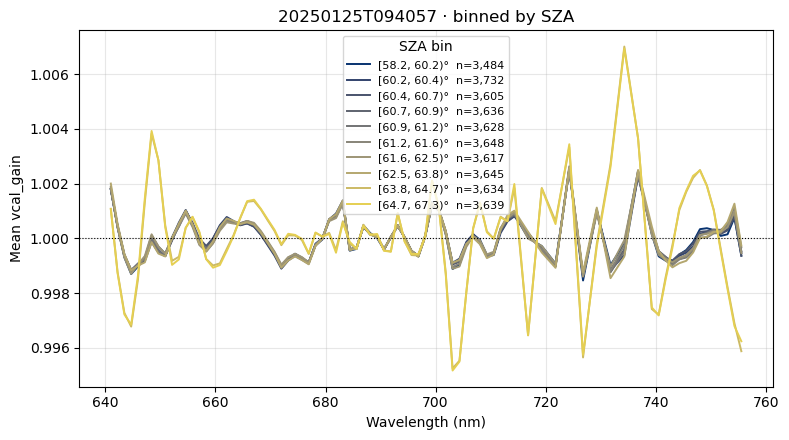

In [27]:
# Bin pixels by SZA (from L1B geolocation); also load VZA
# Prefer path written into the vcal_gain NetCDF attributes
l1b_path = Path(ds.attrs.get("l1b_file", ""))
if not l1b_path.is_file():
    # fallback: dated layout under kiwi L1B_V3
    y, m, d = granule_id[:4], granule_id[4:6], granule_id[6:8]
    l1b_path = (
        Path("/kiwi-data/Data/satellite/PACE_OCI/L1B_V3")
        / y / m / d
        / f"PACE_OCI.{granule_id}.L1B.V3.nc"
    )
assert l1b_path.is_file(), f"L1B not found: {l1b_path}"

# L1B geo is on the same (scans, pixels) grid as vcal_gain
geo = xr.open_dataset(l1b_path, group="geolocation_data")
sza = np.asarray(geo["solar_zenith"].values, dtype=float)   # (scans, pixels)
vza = np.asarray(geo["sensor_zenith"].values, dtype=float)
geo.close()
print(f"L1B: {l1b_path.name}  sza {sza.shape}  range [{np.nanmin(sza):.1f}, {np.nanmax(sza):.1f}]°")

gain_2d = vcal_gain.values.reshape(vcal_gain.sizes["wavelength"], -1)  # (λ, N)
sza_vals = sza.ravel()
valid = np.isfinite(sza_vals) & np.isfinite(gain_2d).any(axis=0)
sza_v = sza_vals[valid]
gain_v = gain_2d[:, valid]

n_bins_sza = 10
# Quantile edges over valid pixels (this granule's dark/ocean SZA span is narrow)
sza_edges = np.unique(np.nanquantile(sza_v, np.linspace(0, 1, n_bins_sza + 1)))
if len(sza_edges) < 3:
    sza_edges = np.linspace(np.nanmin(sza_v), np.nanmax(sza_v), n_bins_sza + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.cm.cividis(np.linspace(0.1, 0.9, max(1, len(sza_edges) - 1)))
for i, (lo, hi) in enumerate(zip(sza_edges[:-1], sza_edges[1:])):
    if i < len(sza_edges) - 2:
        m = (sza_v >= lo) & (sza_v < hi)
    else:
        m = (sza_v >= lo) & (sza_v <= hi)
    if m.sum() == 0:
        continue
    mean_b = np.nanmean(gain_v[:, m], axis=1)
    ax.plot(
        wavelength,
        mean_b,
        color=cmap[i],
        lw=1.4,
        label=f"[{lo:.1f}, {hi:.1f})°  n={m.sum():,}",
    )

ax.axhline(1.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean vcal_gain")
ax.set_title(f"{granule_id} · binned by SZA")
ax.legend(title="SZA bin", fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


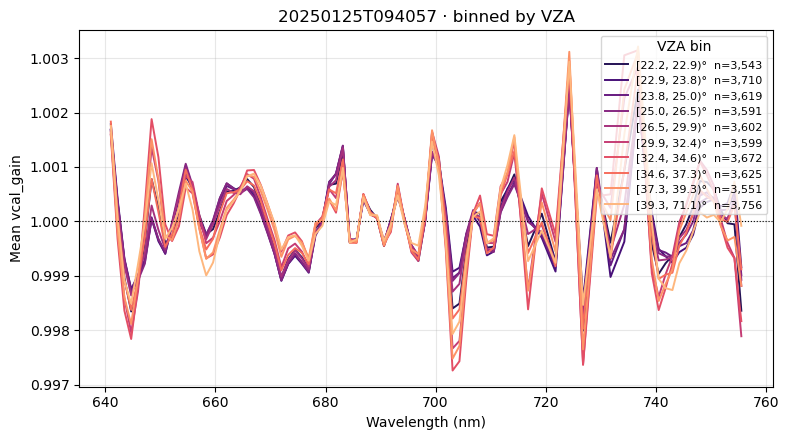

In [28]:
# Bin pixels by VZA (from L1B geolocation; requires `vza` from the SZA cell above)
gain_2d = vcal_gain.values.reshape(vcal_gain.sizes["wavelength"], -1)  # (λ, N)
vza_vals = vza.ravel()
valid = np.isfinite(vza_vals) & np.isfinite(gain_2d).any(axis=0)
vza_v = vza_vals[valid]
gain_v = gain_2d[:, valid]

n_bins_vza = 10
# Quantile edges over valid pixels
vza_edges = np.unique(np.nanquantile(vza_v, np.linspace(0, 1, n_bins_vza + 1)))
if len(vza_edges) < 3:
    vza_edges = np.linspace(np.nanmin(vza_v), np.nanmax(vza_v), n_bins_vza + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.cm.magma(np.linspace(0.15, 0.85, max(1, len(vza_edges) - 1)))
for i, (lo, hi) in enumerate(zip(vza_edges[:-1], vza_edges[1:])):
    if i < len(vza_edges) - 2:
        m = (vza_v >= lo) & (vza_v < hi)
    else:
        m = (vza_v >= lo) & (vza_v <= hi)
    if m.sum() == 0:
        continue
    mean_b = np.nanmean(gain_v[:, m], axis=1)
    ax.plot(
        wavelength,
        mean_b,
        color=cmap[i],
        lw=1.4,
        label=f"[{lo:.1f}, {hi:.1f})°  n={m.sum():,}",
    )

ax.axhline(1.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean vcal_gain")
ax.set_title(f"{granule_id} · binned by VZA")
ax.legend(title="VZA bin", fontsize=8, loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [30]:
npz = np.load("/home/zhe2/data/PACE/new_svd_retrieval_output/vcal_gain/qc_20250125/vcal_gain_20250125_summary.npz")
wavelength = npz["wavelength"]
mean_gain  = npz["mean_gain"]

In [ ]:

# # wavelength, mean_gain: 1D arrays, same length
# np.savetxt(
#     "vcal_gain_mean.txt",
#     np.column_stack([wavelength, mean_gain]),
#     header="wavelength_nm  mean_gain",
#     comments="",
#     fmt="%.6f",
# )